이 노트북은 다음과 같은 질문에 답합니다:
- 어떤 변수가 선수 가치에 영향을 줄까?
- 머신러닝으로 어느 정도 정확히 예측할 수 있을까?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('most_valuable_forwards_fixed.csv') 
df.head()


,이름,나이,국적,소속클럽,선수가치,경기수,골,어시스트,옐로카드,레드카드,교체인,교체아웃
0,Erling Haaland,24,Norway,Manchester City,€200.00m,49,39,5,2,0,1,10
1,Vinicius Junior,24,Brazil,Real Madrid,€200.00m,50,20,16,15,1,7,19
2,Lamine Yamal,17,Spain,FC Barcelona,€180.00m,58,18,26,4,0,4,28
3,Kylian Mbappé,26,France,Real Madrid,€170.00m,57,39,4,5,1,5,19
4,Bukayo Saka,23,England,Arsenal FC,€150.00m,38,12,14,6,0,6,19


In [4]:
# 결측치
print(df.isnull().sum())

이름      0
나이      0
국적      0
소속클럽    0
선수가치    0
경기수     0
골       0
어시스트    0
옐로카드    0
레드카드    0
교체인     0
교체아웃    0
dtype: int64


In [5]:
# 정보
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1225 entries, 0 to 1224
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   이름      1225 non-null   object 
 1   나이      1225 non-null   int64  
 2   국적      1225 non-null   object 
 3   소속클럽    1225 non-null   object 
 4   선수가치    1225 non-null   float64
 5   경기수     1225 non-null   int64  
 6   골       1225 non-null   int64  
 7   어시스트    1225 non-null   int64  
 8   옐로카드    1225 non-null   int64  
 9   레드카드    1225 non-null   int64  
 10  교체인     1225 non-null   int64  
 11  교체아웃    1225 non-null   int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 115.0+ KB
None


In [6]:
# 유일값 확인
print(df.nunique())

이름      498
나이       21
국적       72
소속클럽    165
선수가치     45
경기수      59
골        39
어시스트     26
옐로카드     15
레드카드      3
교체인      33
교체아웃     38
dtype: int64


In [3]:
df['선수가치'] = df['선수가치'].str.replace('€', '').str.replace('m', '').astype(float)
df.head()

,이름,나이,국적,소속클럽,선수가치,경기수,골,어시스트,옐로카드,레드카드,교체인,교체아웃
0,Erling Haaland,24,Norway,Manchester City,200.0,49,39,5,2,0,1,10
1,Vinicius Junior,24,Brazil,Real Madrid,200.0,50,20,16,15,1,7,19
2,Lamine Yamal,17,Spain,FC Barcelona,180.0,58,18,26,4,0,4,28
3,Kylian Mbappé,26,France,Real Madrid,170.0,57,39,4,5,1,5,19
4,Bukayo Saka,23,England,Arsenal FC,150.0,38,12,14,6,0,6,19


In [5]:
df.drop(columns=['이름'], inplace=True)

In [6]:
df = pd.get_dummies(df, columns=['국적', '소속클럽'])

In [7]:
X = df.drop(columns=['선수가치'])
y = df['선수가치']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [10]:
y_pred = model.predict(X_test)

print("✅ MSE (평균제곱오차):", mean_squared_error(y_test, y_pred))
print("✅ R^2 Score (결정계수):", r2_score(y_test, y_pred))

✅ MSE (평균제곱오차): 70.85783214285713
✅ R^2 Score (결정계수): 0.29966307779456935


In [11]:
# matplotlib 한글 깨짐 방지
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Darwin':  # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':  # Windows
    plt.rc('font', family='Malgun Gothic')
else:  # Linux (colab 등)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

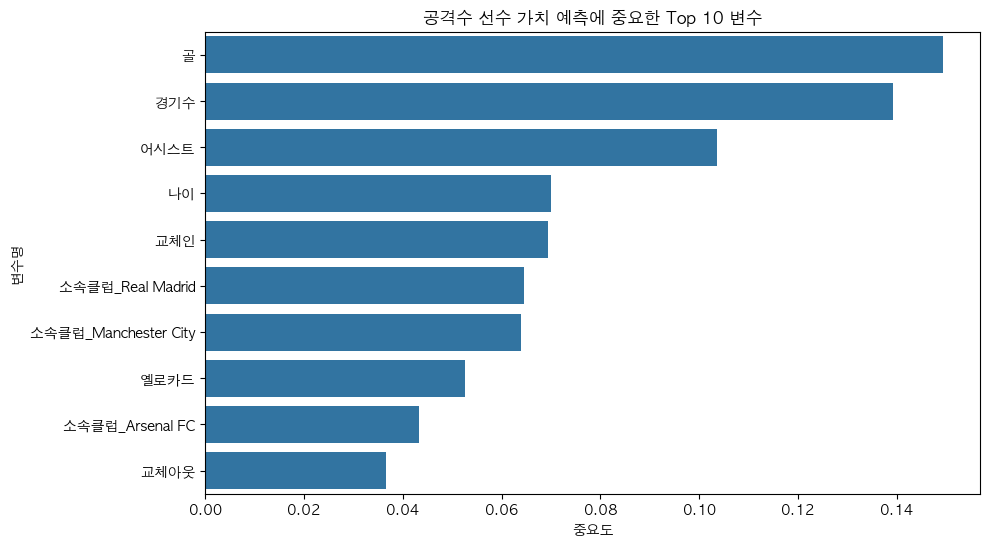

In [12]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index)
plt.title("공격수 선수 가치 예측에 중요한 Top 10 변수")
plt.xlabel("중요도")
plt.ylabel("변수명")
plt.show()